<a href="https://colab.research.google.com/github/jakaaris/FinalTask_HomeCredit/blob/main/FinalTask_HomeCreditScorecardModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **[Final Task] Home Credit Scorecard Model**

# **Starter** 🚀

🏆 Goal

Meningkatkan akurasi penilaian risiko kredit untuk memitigasi potensi kerugian finansial.

🔍 Objective

1. Membangun model Machine Learning yang sangat presisi untuk memprediksi risiko kredit dan mengidentifikasi pemohon berpotensi gagal bayar, serta
2. Menganalisis dan mengidentifikasi faktor-faktor kunci yang paling signifikan berkontribusi terhadap risiko kredit tersebut.

🔴 Metric


*   AUC-ROC
*   Confusion Matrix
*   Recall
*   Precison






# **Exploratory Data Analysis (EDA)**

### **Import Libraries**

In [46]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
import joblib
import re

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [48]:
path_train = '/content/drive/MyDrive/Data_HomeCredit/application_train.csv'
path_test = '/content/drive/MyDrive/Data_HomeCredit/application_test.csv'

# Memuat data latih
train_df = pd.read_csv(path_train)

# Memuat data tes
test_df = pd.read_csv(path_test)

print("--- Data Latih (application_train_1.csv) Berhasil Dimuat ---")
print(f"Bentuk data latih (baris, kolom): {train_df.shape}")

print("\n--- Data Tes (application_test.csv) Berhasil Dimuat ---")
print(f"Bentuk data tes (baris, kolom): {test_df.shape}")

--- Data Latih (application_train_1.csv) Berhasil Dimuat ---
Bentuk data latih (baris, kolom): (307511, 122)

--- Data Tes (application_test.csv) Berhasil Dimuat ---
Bentuk data tes (baris, kolom): (48744, 121)


In [49]:
# Menampilkan 5 baris pertama data latih untuk melihat struktur data
print("\n\n--- 5 Baris Pertama Data Latih ---")
train_df.head()



--- 5 Baris Pertama Data Latih ---


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [50]:
print("\n\n--- Informasi Kolom Data Latih (Tipe Data & Nilai Non-Null) ---")
train_df.info(verbose=True)



--- Informasi Kolom Data Latih (Tipe Data & Nilai Non-Null) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            object 
 3    CODE_GENDER                   object 
 4    FLAG_OWN_CAR                  object 
 5    FLAG_OWN_REALTY               object 
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               object 
 12   NAME_INCOME_TYPE              object 
 13   NAME_EDUCATION_TYPE           object 
 14   NAME_FAMILY_STATUS            object 
 15   NAME_HOUSING_TYPE             object 
 16   REGION_POPULATION_RELATI

In [51]:
# Atur style plot
sns.set(style="whitegrid")


--- Analisis Variabel Target (TARGET) ---
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64
Grafik 'target_distribution.png' disimpan.


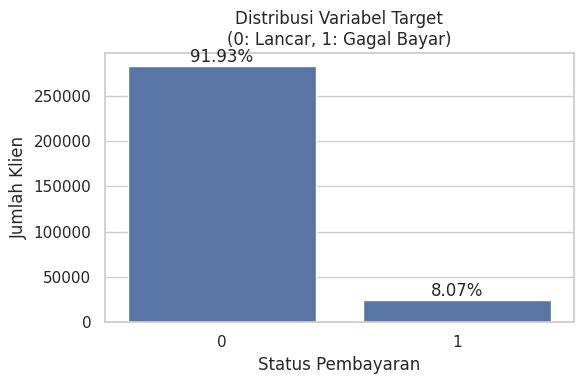

In [52]:
print("\n--- Analisis Variabel Target (TARGET) ---")
target_counts = train_df['TARGET'].value_counts(normalize=True) * 100
print(target_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x='TARGET', data=train_df)
plt.title('Distribusi Variabel Target\n(0: Lancar, 1: Gagal Bayar)')
plt.ylabel('Jumlah Klien')
plt.xlabel('Status Pembayaran')
# Menambahkan anotasi persentase
plt.gca().text(0, target_counts.loc[0] * len(train_df) / 100, f'{target_counts.loc[0]:.2f}%', ha='center', va='bottom')
plt.gca().text(1, target_counts.loc[1] * len(train_df) / 100, f'{target_counts.loc[1]:.2f}%', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('target_distribution.png')
print("Grafik 'target_distribution.png' disimpan.")

Dataset application_train.csv telah dipilih sebagai input untuk analisis dan pemodelan. Data ini menyajikan detail statis dari permohonan pinjaman secara individual. Dengan dimensi sebesar 307.511 baris (entri pinjaman) dan 122 kolom (variabel), dataset ini menyediakan informasi lengkap yang dibutuhkan


--- Analisis Missing Values ---
Kolom dengan persentase missing values tertinggi:
COMMONAREA_MEDI             69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_AVG              69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MEDI              67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_AVG                59.376738
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
dtype: float64
Grafik 'missing_values.png' disimpan.


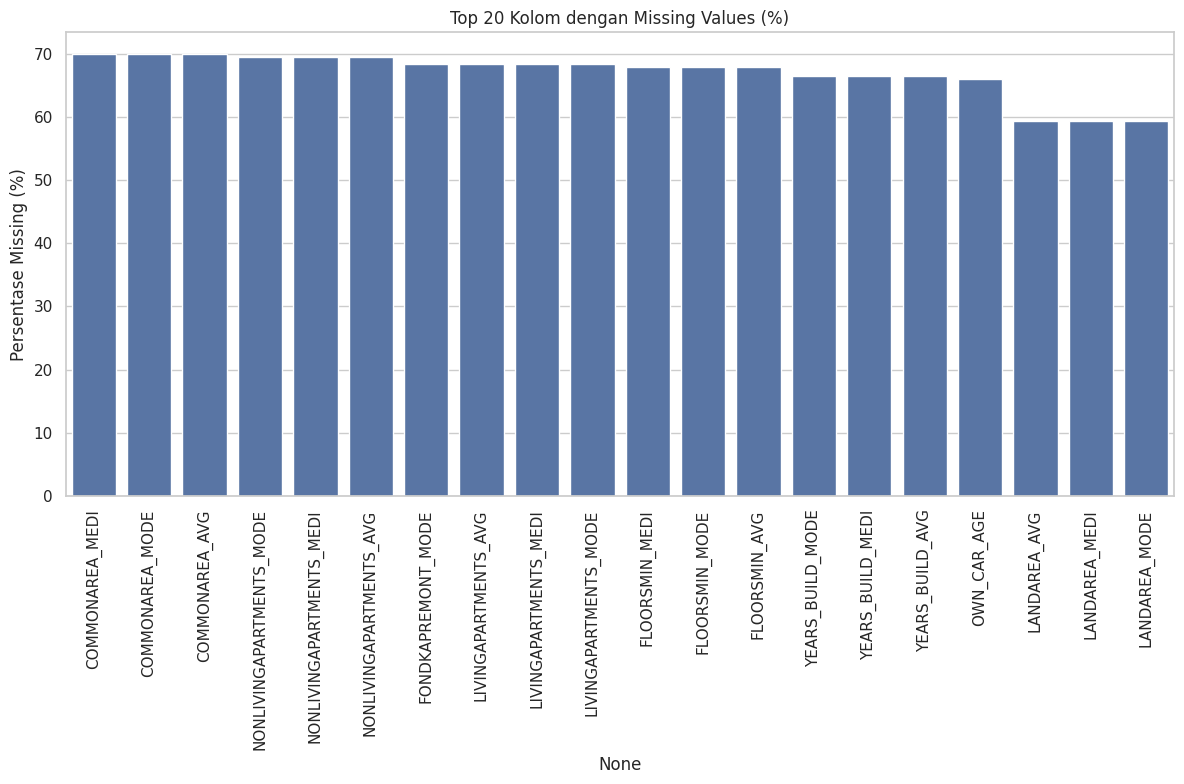

In [53]:
print("\n--- Analisis Missing Values ---")
missing_values = (train_df.isnull().sum() / len(train_df)) * 100
missing_values = missing_values.drop(missing_values[missing_values == 0].index).sort_values(ascending=False)

print("Kolom dengan persentase missing values tertinggi:")
print(missing_values.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(x=missing_values.head(20).index, y=missing_values.head(20).values)
plt.xticks(rotation=90)
plt.title('Top 20 Kolom dengan Missing Values (%)')
plt.ylabel('Persentase Missing (%)')
plt.tight_layout()
plt.savefig('missing_values.png')
print("Grafik 'missing_values.png' disimpan.")



--- Analisis Fitur Numerik (Usia) ---
Grafik 'age_distribution.png' disimpan.

--- Analisis Fitur Numerik (Lama Bekerja) ---


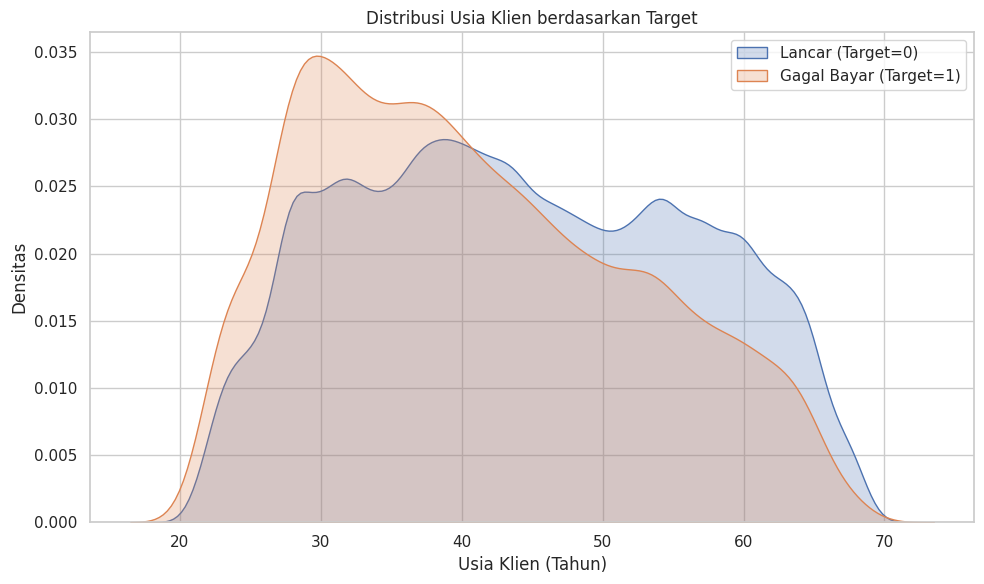

In [54]:
# --- 4. Analisis Fitur Numerik ---
print("\n--- Analisis Fitur Numerik (Usia) ---")
# Konversi DAYS_BIRTH (negatif) ke Usia (positif, dalam tahun)
train_df['DAYS_BIRTH_YEARS'] = train_df['DAYS_BIRTH'] / -365

plt.figure(figsize=(10, 6))
# Plot Kernel Density Estimate (KDE) untuk melihat distribusi
sns.kdeplot(train_df.loc[train_df['TARGET'] == 0, 'DAYS_BIRTH_YEARS'], label='Lancar (Target=0)', fill=True)
sns.kdeplot(train_df.loc[train_df['TARGET'] == 1, 'DAYS_BIRTH_YEARS'], label='Gagal Bayar (Target=1)', fill=True)
plt.xlabel('Usia Klien (Tahun)')
plt.ylabel('Densitas')
plt.title('Distribusi Usia Klien berdasarkan Target')
plt.legend()
plt.tight_layout()
plt.savefig('age_distribution.png')
print("Grafik 'age_distribution.png' disimpan.")

print("\n--- Analisis Fitur Numerik (Lama Bekerja) ---")

In [55]:
# Cek anomali di DAYS_EMPLOYED
anomalies = (train_df['DAYS_EMPLOYED'] == 365243).sum()
print(f"Jumlah anomali di DAYS_EMPLOYED (nilai 365243): {anomalies}")

Jumlah anomali di DAYS_EMPLOYED (nilai 365243): 55374


Grafik 'employment_distribution.png' disimpan.


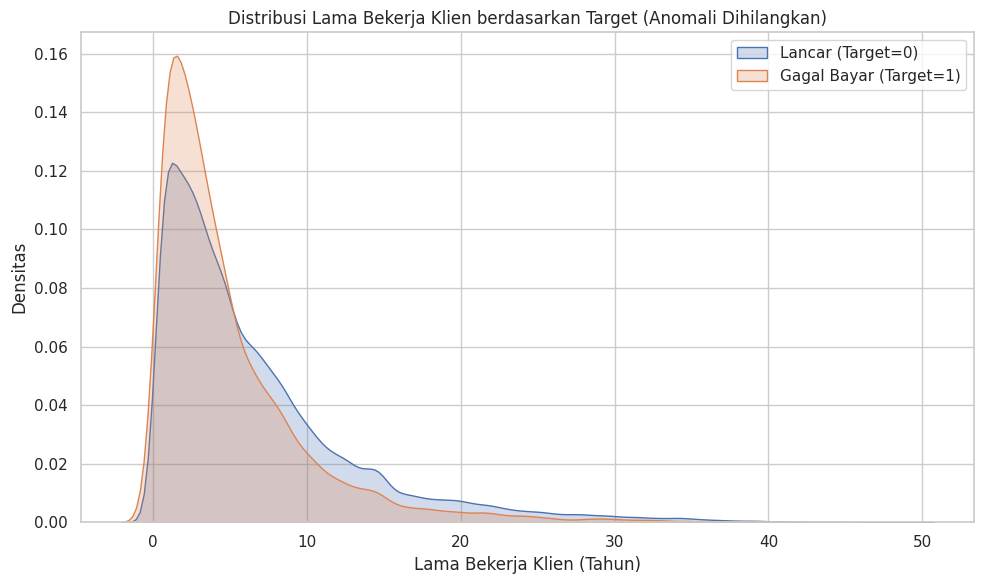

In [56]:
# Ganti anomali dengan NaN agar tidak mengganggu plot
train_df['DAYS_EMPLOYED_NORMALIZED'] = train_df['DAYS_EMPLOYED'].replace({365243: np.nan})
train_df['DAYS_EMPLOYED_YEARS'] = train_df['DAYS_EMPLOYED_NORMALIZED'] / -365

plt.figure(figsize=(10, 6))
sns.kdeplot(train_df.loc[train_df['TARGET'] == 0, 'DAYS_EMPLOYED_YEARS'].dropna(), label='Lancar (Target=0)', fill=True)
sns.kdeplot(train_df.loc[train_df['TARGET'] == 1, 'DAYS_EMPLOYED_YEARS'].dropna(), label='Gagal Bayar (Target=1)', fill=True)
plt.xlabel('Lama Bekerja Klien (Tahun)')
plt.ylabel('Densitas')
plt.title('Distribusi Lama Bekerja Klien berdasarkan Target (Anomali Dihilangkan)')
plt.legend()
plt.tight_layout()
plt.savefig('employment_distribution.png')
print("Grafik 'employment_distribution.png' disimpan.")

Grafik 'default_rate_NAME_INCOME_TYPE.png' disimpan.
Grafik 'default_rate_NAME_EDUCATION_TYPE.png' disimpan.
Grafik 'default_rate_NAME_FAMILY_STATUS.png' disimpan.
Grafik 'default_rate_NAME_HOUSING_TYPE.png' disimpan.


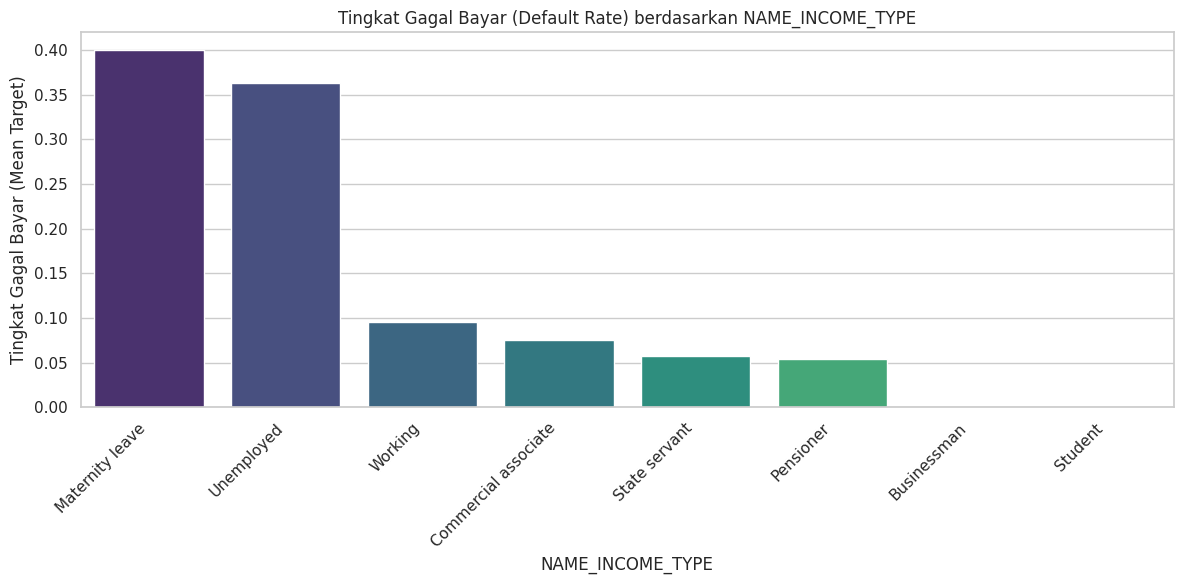

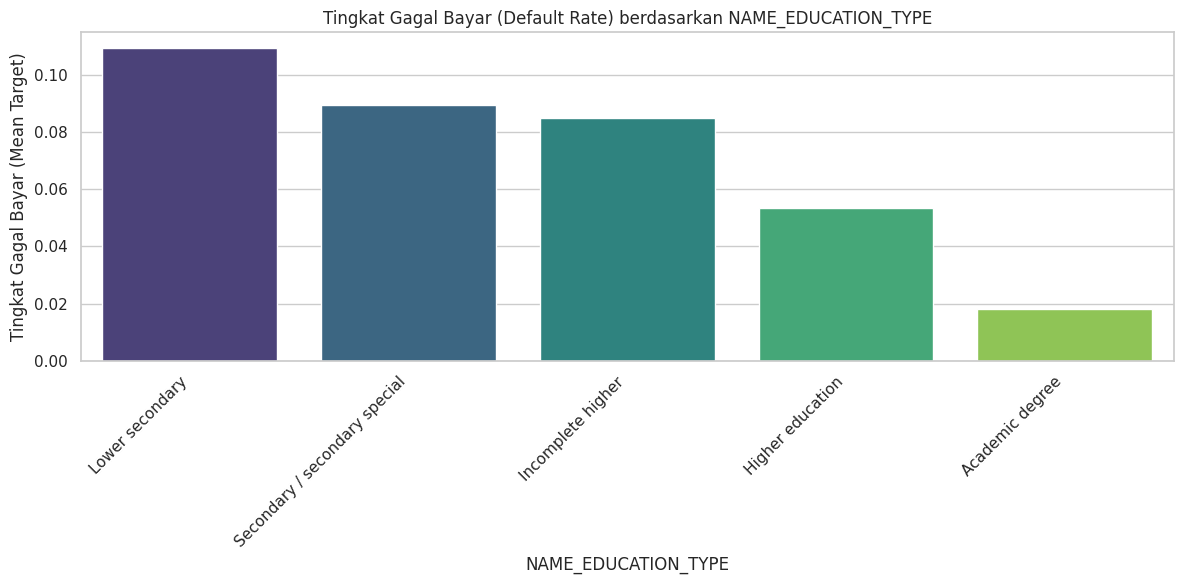

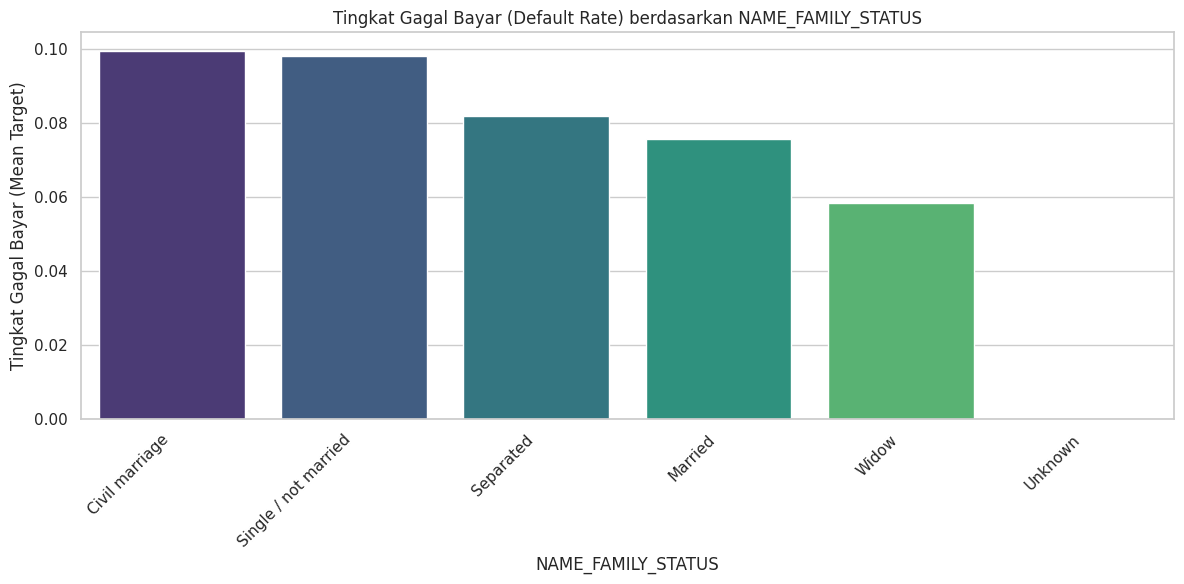

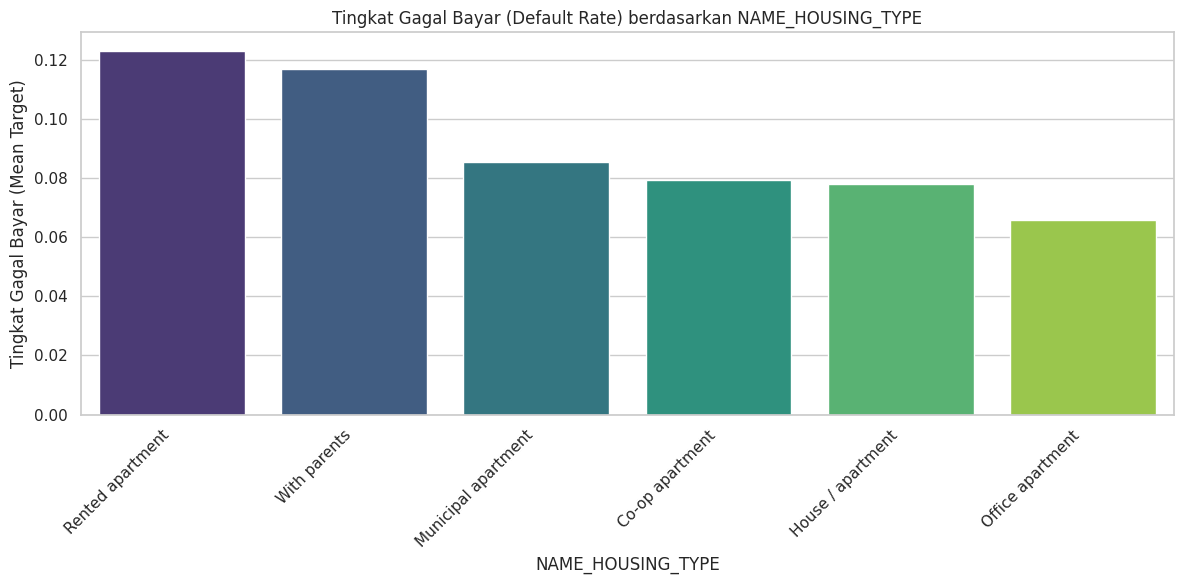

In [57]:
def plot_categorical_vs_target(col_name):
        plt.figure(figsize=(12, 6))
        # Hitung rata-rata TARGET (tingkat gagal bayar) untuk tiap kategori
        data = train_df.groupby(col_name)['TARGET'].mean().sort_values(ascending=False)
        sns.barplot(x=data.index, y=data.values, palette="viridis")
        plt.title(f'Tingkat Gagal Bayar (Default Rate) berdasarkan {col_name}')
        plt.ylabel('Tingkat Gagal Bayar (Mean Target)')
        plt.xlabel(col_name)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(f'default_rate_{col_name}.png')
        print(f"Grafik 'default_rate_{col_name}.png' disimpan.")

# Plot untuk beberapa fitur kategorikal penting
plot_categorical_vs_target('NAME_INCOME_TYPE')
plot_categorical_vs_target('NAME_EDUCATION_TYPE')
plot_categorical_vs_target('NAME_FAMILY_STATUS')
plot_categorical_vs_target('NAME_HOUSING_TYPE')

In [58]:
# --- 2. Persiapan Awal ---
print("Memisahkan variabel target (y_train) dan ID (test_ids)...")
if 'TARGET' in train_df.columns:
    y_train_series = train_df['TARGET']
    X_train_df = train_df.drop('TARGET', axis=1)
else:
    print("Error: Kolom 'TARGET' tidak ditemukan.")
    X_train_df = train_df.copy()
    y_train_series = pd.Series()

if 'SK_ID_CURR' in test_df.columns:
    test_ids_series = test_df['SK_ID_CURR']
else:
    test_ids_series = pd.Series()

if 'SK_ID_CURR' in X_train_df.columns:
    X_train_df = X_train_df.drop('SK_ID_CURR', axis=1)
if 'SK_ID_CURR' in test_df.columns:
    X_test_df = test_df.drop('SK_ID_CURR', axis=1)
else:
    X_test_df = test_df.copy()

Memisahkan variabel target (y_train) dan ID (test_ids)...


In [59]:
# --- 3. Menghapus Kolom dengan Missing Values Tinggi ---
print("Menghapus kolom dengan > 50% missing values...")
missing_percent = (X_train_df.isnull().sum() / len(X_train_df)) * 100
cols_to_drop = missing_percent[missing_percent > 50].index.tolist()
X_train_df = X_train_df.drop(columns=cols_to_drop)
X_test_df = X_test_df.drop(columns=cols_to_drop, errors='ignore')


Menghapus kolom dengan > 50% missing values...


In [60]:
# --- 4. Menangani Anomali ---
print("Menangani anomali di 'DAYS_EMPLOYED'...")
X_train_df['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace=True)
X_test_df['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace=True)

Menangani anomali di 'DAYS_EMPLOYED'...


In [61]:
# --- 5. Identifikasi Tipe Kolom ---
# Redefine numerical_cols and categorical_cols AFTER dropping columns and handling anomalies
categorical_cols = X_train_df.select_dtypes('object').columns.tolist()
numerical_cols = X_train_df.select_dtypes(np.number).columns.tolist()

categorical_cols = X_test_df.select_dtypes('object').columns.tolist()
numerical_cols = X_test_df.select_dtypes(np.number).columns.tolist()

In [62]:
# --- 6. Imputasi Missing Values ---
print("Melakukan imputasi (mengisi) missing values...")
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train_df[numerical_cols] = num_imputer.fit_transform(X_train_df[numerical_cols])
X_train_df[categorical_cols] = cat_imputer.fit_transform(X_train_df[categorical_cols])

X_test_df[numerical_cols] = num_imputer.transform(X_test_df[numerical_cols])
X_test_df[categorical_cols] = cat_imputer.transform(X_test_df[categorical_cols])

Melakukan imputasi (mengisi) missing values...


In [63]:
# --- 7. Encoding Variabel Kategorikal ---
print("Melakukan One-Hot Encoding...")
X_train_df = pd.get_dummies(X_train_df, columns=categorical_cols, dummy_na=False)
X_test_df = pd.get_dummies(X_test_df, columns=categorical_cols, dummy_na=False)

Melakukan One-Hot Encoding...


In [64]:
# --- 8. Penyesuaian (Alignment) Kolom ---
print("Menyesuaikan (align) kolom data latih dan tes...")
train_cols = X_train_df.columns
X_test_df = X_test_df.reindex(columns=train_cols, fill_value=0)


Menyesuaikan (align) kolom data latih dan tes...


In [65]:
# --- 9. Feature Scaling ---
print("Melakukan Feature Scaling (StandardScaler)...")
# numerical_cols needs to be redefined again after one-hot encoding
numerical_cols = X_train_df.select_dtypes(np.number).columns.tolist()
scaler = StandardScaler()
X_train_df[numerical_cols] = scaler.fit_transform(X_train_df[numerical_cols])
X_test_df[numerical_cols] = scaler.transform(X_test_df[numerical_cols])

Melakukan Feature Scaling (StandardScaler)...


In [66]:
# --- 10. Menyimpan Data yang Sudah Diproses ---
print("Menyimpan data yang sudah bersih ke file CSV...")
X_train_df.to_csv('X_train_processed.csv', index=False)
X_test_df.to_csv('X_test_processed.csv', index=False)
y_train_series.to_csv('y_train.csv', index=False, header=True) # Simpan dengan header 'TARGET'
test_ids_series.to_csv('test_ids.csv', index=False, header=True)


Menyimpan data yang sudah bersih ke file CSV...


In [67]:
# Data sudah ada di variabel X_train_df dan y_train_series
X_train_loaded = X_train_df
y_train_loaded = y_train_series

In [68]:
# --- 2. Melatih Model Awal untuk Feature Importance ---
print("\nMelatih model RandomForestClassifier untuk mendapatkan feature importance...")
# Kita gunakan parameter sederhana.
# class_weight='balanced' penting karena data kita imbalanced
model_rf = RandomForestClassifier(n_estimators=100,
                                  class_weight='balanced',
                                  random_state=42,
                                  n_jobs=-1,
                                  max_depth=10) # Batasi kedalaman agar lebih cepat

model_rf.fit(X_train_loaded, y_train_loaded)
print("Model selesai dilatih.")


Melatih model RandomForestClassifier untuk mendapatkan feature importance...
Model selesai dilatih.


In [69]:
# --- 3. Ekstraksi dan Plot Feature Importance ---
print("Mengekstrak feature importance...")
importances = model_rf.feature_importances_
feature_names = X_train_loaded.columns

Mengekstrak feature importance...



Top 20 Fitur Paling Penting:
                                              feature  importance
27                                       EXT_SOURCE_3    0.181083
26                                       EXT_SOURCE_2    0.157592
68                                DAYS_EMPLOYED_YEARS    0.049836
67                           DAYS_EMPLOYED_NORMALIZED    0.044473
66                                   DAYS_BIRTH_YEARS    0.036559
4                                     AMT_GOODS_PRICE    0.032327
6                                          DAYS_BIRTH    0.029847
7                                       DAYS_EMPLOYED    0.029159
39                             DAYS_LAST_PHONE_CHANGE    0.027928
94               NAME_EDUCATION_TYPE_Higher education    0.027838
2                                          AMT_CREDIT    0.021385
9                                     DAYS_ID_PUBLISH    0.018512
3                                         AMT_ANNUITY    0.017772
97  NAME_EDUCATION_TYPE_Secondary / secondary 

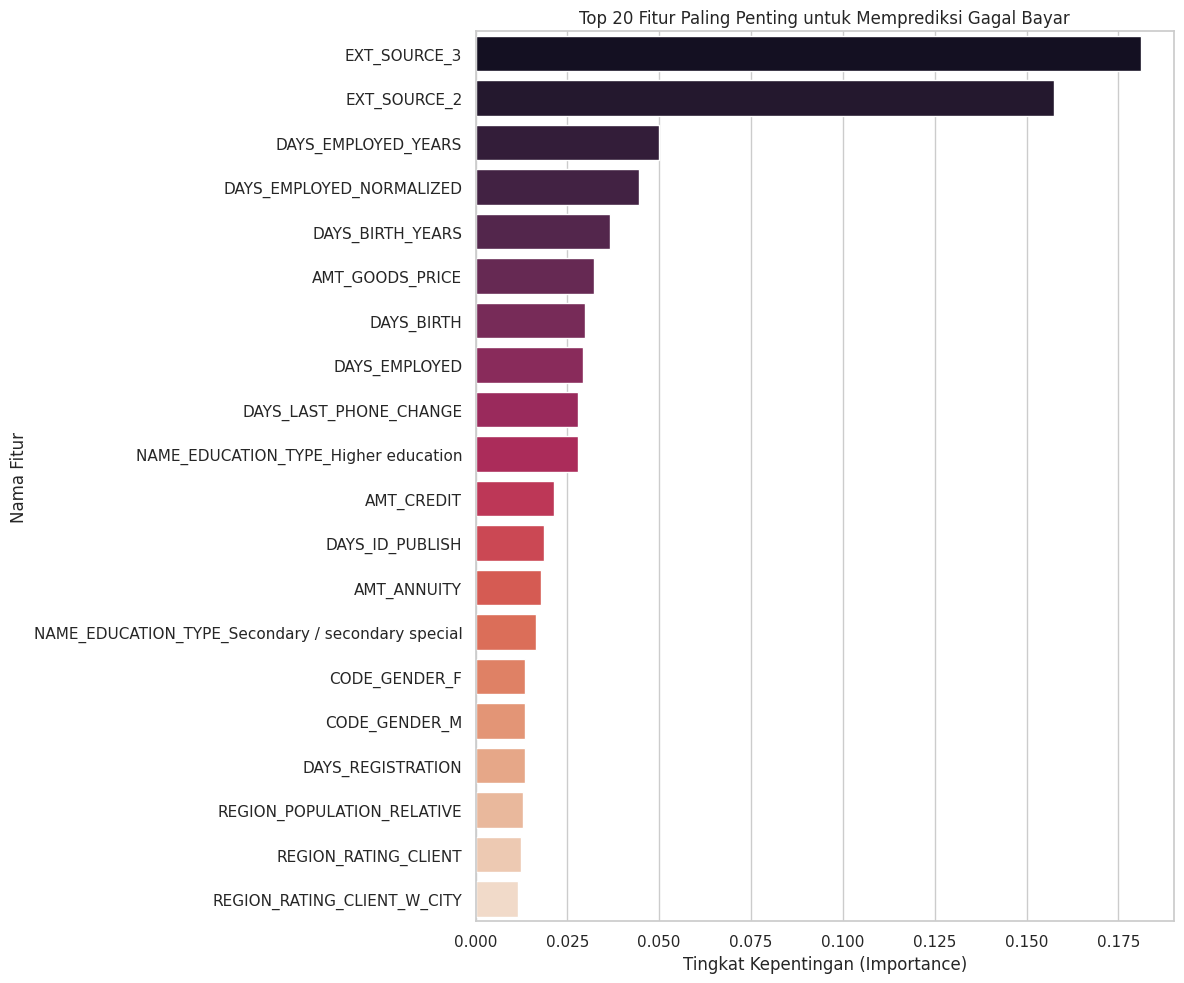

In [70]:
# Buat DataFrame untuk memudahkan sorting
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

# Sort berdasarkan importance
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Ambil Top 20
top_20_features = feature_importance_df.head(20)

print("\nTop 20 Fitur Paling Penting:")
print(top_20_features)

# --- 4. Plotting ---
sns.set(style="whitegrid")
print("\nMembuat plot feature importance...")
plt.figure(figsize=(12, 10))
sns.barplot(x='importance', y='feature', data=top_20_features, palette='rocket')
plt.title('Top 20 Fitur Paling Penting untuk Memprediksi Gagal Bayar')
plt.xlabel('Tingkat Kepentingan (Importance)')
plt.ylabel('Nama Fitur')
plt.tight_layout()
plt.savefig('feature_importance.png')
print("Grafik 'feature_importance.png' disimpan.")

In [71]:
# --- Memuat Data yang Sudah Diproses ---
print("Memuat data X_train_processed.csv dan y_train.csv...")
try:
    X_train = pd.read_csv('/content/X_train_processed.csv')
    y_train = pd.read_csv('/content/y_train.csv').squeeze("columns")
except FileNotFoundError:
    print("Error: File 'X_train_processed.csv' or 'y_train.csv' tidak ditemukan.")
    print("Harap jalankan ulang kode dari Tugas 6 & 7.")
    raise FileNotFoundError


Memuat data X_train_processed.csv dan y_train.csv...


In [72]:
# ---  Membagi Data (Train/Validation Split) ---
print("\nMembagi data menjadi set latih (80%) dan validasi (20%)...")
# y_train_split dan y_val sekarang akan bertipe integer
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)
print(f"Bentuk X_train_split: {X_train_split.shape}")
print(f"Bentuk X_val: {X_val.shape}")
print(f"Tipe data y_val: {y_val.dtype}") # Konfirmasi tipe data



Membagi data menjadi set latih (80%) dan validasi (20%)...
Bentuk X_train_split: (246008, 195)
Bentuk X_val: (61503, 195)
Tipe data y_val: int64


In [73]:
# --- Add Imputation Step Here ---
print("\nMelakukan imputasi pada data split...")
# Identify numerical columns in the split data *right before imputation*
numerical_cols_split = X_train_split.select_dtypes(np.number).columns.tolist()


Melakukan imputasi pada data split...


In [74]:
# Initialize and fit the imputer
imputer_split = SimpleImputer(strategy='median')
X_train_split[numerical_cols_split] = imputer_split.fit_transform(X_train_split[numerical_cols_split])

# Apply the fitted imputer to the validation set
# Ensure numerical_cols_split reflects columns in X_val as well (should be same after alignment)
X_val[numerical_cols_split] = imputer_split.transform(X_val[numerical_cols_split])

print("Imputation finished.")

Imputation finished.


In [75]:
# --- Check for NaNs after Imputation ---
print("\nChecking for NaNs in X_train_split after imputation:")
print(X_train_split.isnull().sum().sum()) # Print total number of NaNs
print("Checking for NaNs in X_val after imputation:")
print(X_val.isnull().sum().sum()) # Print total number of NaNs
# --- End Check ---



Checking for NaNs in X_train_split after imputation:
0
Checking for NaNs in X_val after imputation:
0


In [76]:
# Model 1: Logistic Regression
print("\n--- 1. Melatih Logistic Regression ---")
print("Melakukan GridSearchCV untuk parameter 'C'...")
param_grid_lr = {'C': [0.01, 0.1, 1]}
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, solver='liblinear')
grid_lr = GridSearchCV(lr, param_grid_lr, cv=3, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train_split, y_train_split)
model_lr = grid_lr.best_estimator_
print(f"Parameter terbaik untuk Logistic Regression: {grid_lr.best_params_}")


--- 1. Melatih Logistic Regression ---
Melakukan GridSearchCV untuk parameter 'C'...
Parameter terbaik untuk Logistic Regression: {'C': 0.01}


In [77]:
# Model 2: Random Forest
print("\n--- 2. Melatih Random Forest ---")
model_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train_split, y_train_split)
print("Random Forest selesai dilatih.")


--- 2. Melatih Random Forest ---
Random Forest selesai dilatih.


In [78]:
print("\n\n---  EVALUASI MODEL (PADA SET VALIDASI) ---")

models = {
    "Logistic Regression": model_lr,
    "Random Forest": model_rf,

}



---  EVALUASI MODEL (PADA SET VALIDASI) ---


In [79]:
roc_curves = {}

for name, model in models.items():
    print(f"\n--- Evaluasi untuk: {name} ---")

    y_pred_proba = model.predict_proba(X_val)[:, 1]
    y_pred = model.predict(X_val)


    auc = roc_auc_score(y_val, y_pred_proba)
    print(f"Skor AUC-ROC: {auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, target_names=['Lancar (0)', 'Gagal Bayar (1)']))


--- Evaluasi untuk: Logistic Regression ---
Skor AUC-ROC: 0.7455

Classification Report:
                 precision    recall  f1-score   support

     Lancar (0)       0.96      0.69      0.80     56538
Gagal Bayar (1)       0.16      0.67      0.26      4965

       accuracy                           0.69     61503
      macro avg       0.56      0.68      0.53     61503
   weighted avg       0.90      0.69      0.76     61503


--- Evaluasi untuk: Random Forest ---
Skor AUC-ROC: 0.7318

Classification Report:
                 precision    recall  f1-score   support

     Lancar (0)       0.95      0.77      0.85     56538
Gagal Bayar (1)       0.18      0.56      0.27      4965

       accuracy                           0.75     61503
      macro avg       0.56      0.66      0.56     61503
   weighted avg       0.89      0.75      0.80     61503



Confusion Matrix:


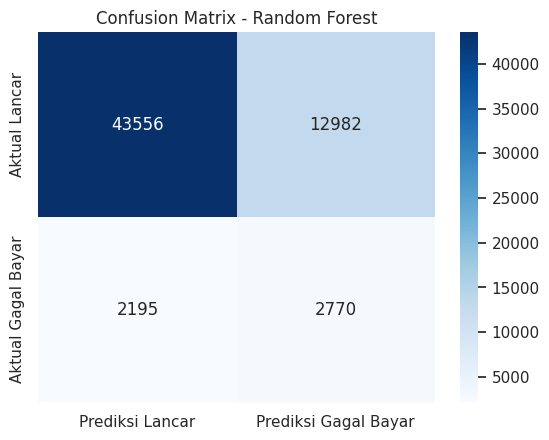

Grafik confusion_matrix_Random_Forest.png disimpan.


<Figure size 640x480 with 0 Axes>

In [90]:
    print("Confusion Matrix:")
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Prediksi Lancar', 'Prediksi Gagal Bayar'],
                yticklabels=['Aktual Lancar', 'Aktual Gagal Bayar'])
    plt.title(f'Confusion Matrix - {name}')
    plt.show()
    plt.savefig(f'confusion_matrix_{name.replace(" ", "_")}.png')
    print(f'Grafik confusion_matrix_{name.replace(" ", "_")}.png' + " disimpan.")
    plt.clf()


    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    roc_curves[name] = (fpr, tpr, auc)



Membuat plot perbandingan ROC Curve...
Grafik 'roc_curves_comparison.png' disimpan.


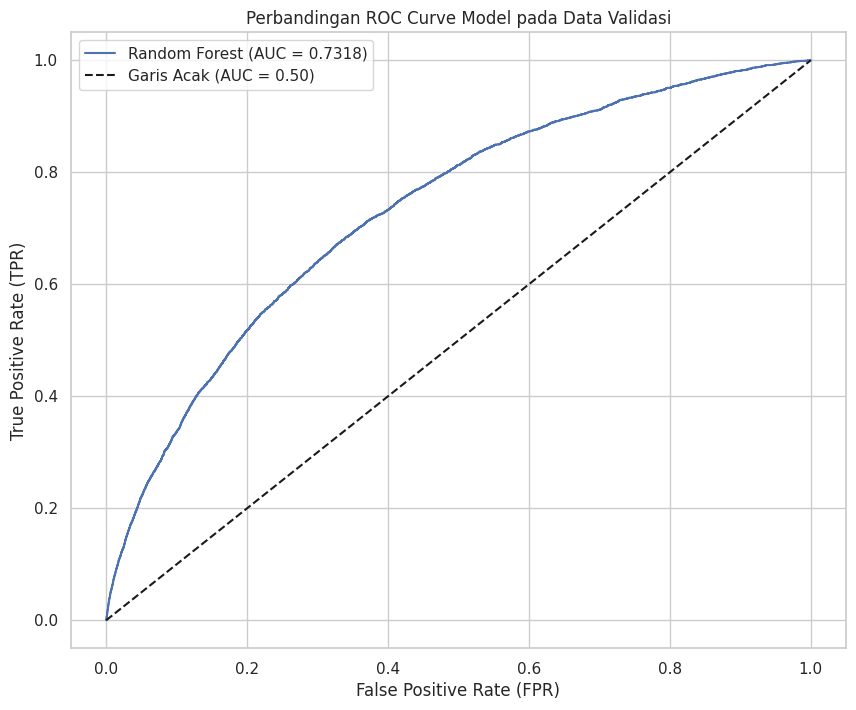

In [81]:
# --- Plot ROC Curve Gabungan ---
print("\nMembuat plot perbandingan ROC Curve...")
plt.figure(figsize=(10, 8))
for name, (fpr, tpr, auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Garis Acak (AUC = 0.50)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Perbandingan ROC Curve Model pada Data Validasi')
plt.legend()
plt.grid(True)
plt.savefig('roc_curves_comparison.png')
print("Grafik 'roc_curves_comparison.png' disimpan.")


In [82]:
# ---  Menyimpan Model ---
print("\nMenyimpan model yang sudah dilatih...")
joblib.dump(model_lr, 'model_logistic_regression.joblib')
joblib.dump(model_rf, 'model_random_forest.joblib')
print("Model berhasil disimpan sebagai file .joblib")



Menyimpan model yang sudah dilatih...
Model berhasil disimpan sebagai file .joblib


In [83]:
print("--- Memulai Pengujian pada Data Tes  ---")

# --- 1. Memuat Data Tes yang Sudah Diproses ---
print("Memuat data X_test_processed.csv dan test_ids.csv...")
try:
    X_test_processed = pd.read_csv('/content/X_test_processed.csv')
    test_ids = pd.read_csv('/content/test_ids.csv').squeeze("columns")
    print("Data tes berhasil dimuat.")
except FileNotFoundError:
    print("Error: File 'X_test_processed.csv' atau 'test_ids.csv' tidak ditemukan.")
    raise FileNotFoundError

--- Memulai Pengujian pada Data Tes  ---
Memuat data X_test_processed.csv dan test_ids.csv...
Data tes berhasil dimuat.


In [84]:

# --- FIX: Menyamakan Nama Kolom Data Tes ---
# Kita harus membersihkan nama kolom X_test persis seperti yang kita lakukan
# pada X_train di Tugas 8/9 agar model dapat mengenali fiturnya.
print("Membersihkan nama kolom data tes (menyamakan dengan data latih)...")
X_test_processed.columns = [re.sub(r'[^A-Za-z0-9_]+', '', col) for col in X_test_processed.columns]
print("Nama kolom telah dibersihkan.")


Membersihkan nama kolom data tes (menyamakan dengan data latih)...
Nama kolom telah dibersihkan.


In [85]:
# --- 3. Memuat Model Terbaik ---
# Kita asumsikan Random Forest adalah model terbaik
print("Memuat model terbaik (model_random_forest.joblib)...")
try:
    best_model = joblib.load('model_random_forest.joblib')
    print("Model berhasil dimuat.")
except FileNotFoundError:
    print("Error: File model 'model_random_forest.joblib' tidak ditemukan.")
    print("Harap jalankan ulang kode dari Tugas 8 & 9.")
    raise FileNotFoundError
except Exception as e:
    print(f"Error saat memuat model: {e}")
    raise e


Memuat model terbaik (model_random_forest.joblib)...
Model berhasil dimuat.


In [86]:
# --- 4. Melakukan Prediksi Probabilitas ---
print("Melakukan prediksi probabilitas pada data tes...")

# Ensure test set columns match training set columns
# We need the columns from the data the model was trained on.
# Based on the notebook history, X_train_loaded was used for training the RF model.
# Make sure X_test_processed has the same columns in the same order.
train_cols = X_train_loaded.columns
X_test_processed = X_test_processed.reindex(columns=train_cols, fill_value=0)


# Model sklearn standar (Random Forest, Logistic Regression)
# menggunakan .predict_proba() sederhana
test_probabilities = best_model.predict_proba(X_test_processed)[:, 1]

print("Prediksi selesai.")

Melakukan prediksi probabilitas pada data tes...
Prediksi selesai.


In [87]:
# --- 5. Membuat File Submission ---
print("Membuat file submission.csv...")
submission_df = pd.DataFrame({
    'SK_ID_CURR': test_ids,
    'TARGET': test_probabilities # Kolom ini berisi probabilitas
})
submission_df['TARGET_ROUNDED_1_DECIMAL'] = submission_df['TARGET'].round(1)

Membuat file submission.csv...


In [88]:
submission_df.to_csv('submission.csv', index=False)

print("\n--- Pengujian Selesai ---")
print("File 'submission.csv' telah berhasil dibuat.")
print("File ini berisi ID klien tes beserta probabilitas gagal bayar (skor kredit).")
print(submission_df.head())


--- Pengujian Selesai ---
File 'submission.csv' telah berhasil dibuat.
File ini berisi ID klien tes beserta probabilitas gagal bayar (skor kredit).
   SK_ID_CURR    TARGET  TARGET_ROUNDED_1_DECIMAL
0      100001  0.423409                       0.4
1      100005  0.616024                       0.6
2      100013  0.367180                       0.4
3      100028  0.257658                       0.3
4      100038  0.567219                       0.6
